<a href="https://colab.research.google.com/github/isil-ada/stellar-mlp-classification/blob/main/2_overfitting_underfitting_analizi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stellar Classification - MLP ile Çoklu Sınıflandırma**

Bu notebook, Stellar Classification dataseti üzerinde sıfırdan NumPy ile yazılmış bir MLP modelini çoklu sınıflandırma (multiclass) için uyarlamaktadır.

**Adımlar:**
1. Veri setini yükleme
2. Özellik mühendisliği (Feature Engineering)
3. Standardizasyon & Normalizasyon
4. MLP yapısını tanımlama (Softmax çıkış katmanı)
5. Model parametrelerini başlatma
6. İleri yayılım (Forward Propagation)
7. Maliyet hesaplama (Categorical Cross-Entropy)
8. Geri yayılım (Backpropagation)
9. Parametre güncelleme
10. Overfitting ve Underfitting analizi

# **1. Veri Setini Yükleme**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/star_classification.csv.zip")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [4]:
df.head(10)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
5,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
6,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
7,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
8,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
9,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232


In [5]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [6]:
df.isnull().sum()

,0
obj_ID,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
run_ID,0
rerun_ID,0


In [7]:
print("Sınıf dağılımı:")
print(df['class'].value_counts())

Sınıf dağılımı:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


# **2. Özellik Mühendisliği (Feature Engineering)**

Stellar veri setinde u, g, r, i, z fotometrik bantları vardır.
Astronomide bu bantların farkları (renk indeksleri) çok anlamlı özelliklerdir.
Yeni özellikler türetiyoruz:
- **u-g**: Mor-Yeşil renk indeksi
- **g-r**: Yeşil-Kırmızı renk indeksi
- **r-i**: Kırmızı-İnfrared renk indeksi
- **i-z**: İnfrared renk indeksi
- **u-r**: Geniş renk indeksi

In [8]:
# ID niteliğindeki sütunları çıkar (bilgi taşımaz)
drop_cols = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
df_clean = df.drop(columns=drop_cols).copy()

print("Temizleme sonrası sütunlar:", df_clean.columns.tolist())

Temizleme sonrası sütunlar: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift']


In [9]:
# Renk indeksleri türet (astronomik özellik mühendisliği)
df_clean['u_g'] = df_clean['u'] - df_clean['g']   # Mor - Yeşil
df_clean['g_r'] = df_clean['g'] - df_clean['r']   # Yeşil - Kırmızı
df_clean['r_i'] = df_clean['r'] - df_clean['i']   # Kırmızı - İnfrared
df_clean['i_z'] = df_clean['i'] - df_clean['z']   # İnfrared farkı
df_clean['u_r'] = df_clean['u'] - df_clean['r']   # Geniş renk aralığı

# redshift karesi (non-lineer ilişkiyi yakalamak için)
df_clean['redshift_sq'] = df_clean['redshift'] ** 2

print("Özellik mühendisliği sonrası sütunlar:")
print(df_clean.columns.tolist())
print("\nDataset boyutu:", df_clean.shape)

Özellik mühendisliği sonrası sütunlar:
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'redshift_sq']

Dataset boyutu: (100000, 15)


# **3. Standardizasyon & Normalizasyon**

- **Label Encoding**: Kategorik sınıf etiketlerini sayısal değerlere dönüştürme (GALAXY=0, QSO=1, STAR=2)
- **One-Hot Encoding**: Çoklu sınıflandırma için hedef vektörü one-hot matrisine dönüştürme
- **StandardScaler**: Özellikleri ortalama=0, std=1 olacak şekilde ölçeklendirme
- **MinMaxScaler**: Özellikleri [0,1] aralığına normalize etme (redshift için)

In [10]:
# Hedef değişkeni encode et
le = LabelEncoder()
df_clean['class_encoded'] = le.fit_transform(df_clean['class'])

print("Sınıf etiketleri:", le.classes_)
print("Encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

Sınıf etiketleri: ['GALAXY' 'QSO' 'STAR']
Encoding: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


In [11]:
# X ve y ayır
feature_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
                'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'redshift_sq']

X = df_clean[feature_cols].copy()
y_raw = df_clean['class_encoded'].values  # 0, 1, 2

print("X shape:", X.shape)
print("y shape:", y_raw.shape)
print("Sınıf değerleri:", np.unique(y_raw))

X shape: (100000, 14)
y shape: (100000,)
Sınıf değerleri: [0 1 2]


In [12]:
# Sadece StandardScaler uygula (MinMaxScaler zincirleme kaldırıldı)
# MinMaxScaler gradyanı bozduğu için kullanılmıyor
scaler_std = StandardScaler()
X_normalized = scaler_std.fit_transform(X)  # Direkt normalized olarak kullanılıyor

print("StandardScaler sonrası:")
print("  Ortalama (ilk 5 özellik):", X_normalized[:, :5].mean(axis=0).round(4))
print("  Std (ilk 5 özellik):", X_normalized[:, :5].std(axis=0).round(4))


StandardScaler sonrası:
  Ortalama (ilk 5 özellik): [-0.  0.  0.  0.  0.]
  Std (ilk 5 özellik): [1. 1. 1. 1. 1.]


In [13]:
# Veriyi karıştır
np.random.seed(42)
shuffle_idx = np.random.permutation(len(X_normalized))
X_normalized = X_normalized[shuffle_idx]
y_raw = y_raw[shuffle_idx]

print("Veri karıştırıldı. X shape:", X_normalized.shape)

Veri karıştırıldı. X shape: (100000, 14)


In [14]:
# Train / Validation / Test split (%70 / %10 / %20)
# Tek seferlik yapılır, kod boyunca bu split kullanılır
X_train, X_temp, y_train_raw, y_temp_raw = train_test_split(
    X_normalized, y_raw, test_size=0.30, random_state=42, stratify=y_raw
)
X_val, X_test, y_val_raw, y_test_raw = train_test_split(
    X_temp, y_temp_raw, test_size=0.667, random_state=42, stratify=y_temp_raw
)

print(f'Train : {X_train.shape[0]:6d} örnek  (%70)')
print(f'Val   : {X_val.shape[0]:6d} örnek  (%10)')
print(f'Test  : {X_test.shape[0]:6d} örnek  (%20)')


Train :  70000 örnek  (%70)
Val   :   9990 örnek  (%10)
Test  :  20010 örnek  (%20)


In [15]:
# One-Hot Encoding fonksiyonu
def one_hot_encode(y, num_classes):
    """
    y: (m,) integer dizisi
    Döndürür: (m, num_classes) one-hot matris
    """
    m = len(y)
    one_hot = np.zeros((m, num_classes))
    one_hot[np.arange(m), y] = 1
    return one_hot

num_classes = 3  # GALAXY, QSO, STAR

y_train = one_hot_encode(y_train_raw, num_classes)
y_val   = one_hot_encode(y_val_raw,   num_classes)
y_test  = one_hot_encode(y_test_raw,  num_classes)

print('y_train shape:', y_train.shape)
print('y_val   shape:', y_val.shape)
print('y_test  shape:', y_test.shape)


y_train shape: (70000, 3)
y_val   shape: (9990, 3)
y_test  shape: (20010, 3)


In [16]:
print('Train class distribution:')
unique, counts = np.unique(y_train_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {le.classes_[u]}: {c}')

print('\nVal class distribution:')
unique, counts = np.unique(y_val_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {le.classes_[u]}: {c}')

print('\nTest class distribution:')
unique, counts = np.unique(y_test_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {le.classes_[u]}: {c}')


Train class distribution:
  GALAXY: 41611
  QSO: 13273
  STAR: 15116

Val class distribution:
  GALAXY: 5939
  QSO: 1894
  STAR: 2157

Test class distribution:
  GALAXY: 11895
  QSO: 3794
  STAR: 4321


# **4. Model Mimarisi (Define Network Structure)**

- **Giriş katmanı**: X.shape[1] = 14 nöron (14 özellik)
- **Gizli katman**: n_h nöron, aktivasyon = tanh
- **Çıkış katmanı**: 3 nöron (3 sınıf), aktivasyon = **Softmax**

Softmax: Çoklu sınıflandırmada kullanılır. Her sınıf için olasılık üretir, toplamları 1'dir.
$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

In [17]:
print("X.shape:", X_train.shape)
print("X.shape[1] (giriş nöron sayısı):", X_train.shape[1])
print("Çıkış nöron sayısı (n_y):", num_classes)

X.shape: (70000, 14)
X.shape[1] (giriş nöron sayısı): 14
Çıkış nöron sayısı (n_y): 3


# **5. Modeli Başlatmak (Initialize Model Parameters)**

In [18]:
def initialize_parameters(n_x, n_h, n_y):
    """
    n_x: giriş katmanı boyutu
    n_h: gizli katman nöron sayısı
    n_y: çıkış katmanı boyutu (sınıf sayısı)

    He Initialization kullanılır:
    W ~ N(0, sqrt(2/n_in)) — tanh/relu için optimal başlangıç
    0.01 * randn yerine He init, softmax çıktısının başlangıçta
    dengeli olmasını ve gradyanın düzgün akmasını sağlar.
    """
    np.random.seed(42)
    W1 = np.random.randn(n_h, n_x) * np.sqrt(2.0 / n_x)  # He init
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * np.sqrt(2.0 / n_h)  # He init
    b2 = np.zeros((n_y, 1))

    parameters = {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }
    return parameters


In [19]:
test_parameters = initialize_parameters(X_train.shape[1], 10, num_classes)

print("W1 shape:", test_parameters["W1"].shape)  # (n_h, n_x)
print("b1 shape:", test_parameters["b1"].shape)  # (n_h, 1)
print("W2 shape:", test_parameters["W2"].shape)  # (n_y, n_h)  ← 3 sınıf
print("b2 shape:", test_parameters["b2"].shape)  # (n_y, 1)

W1 shape: (10, 14)
b1 shape: (10, 1)
W2 shape: (3, 10)
b2 shape: (3, 1)


# **6. İleri Yayılım (Forward Propagation)**

Binary'den farkı:
- Çıkış aktivasyonu: **sigmoid** → **softmax**
- A2 shape: (1, m) → **(n_classes, m)**

In [20]:
def softmax(Z):
    """
    Z: (n_y, m) şeklinde ham skor matrisi
    Döndürür: (n_y, m) şeklinde olasılık matrisi

    Numerik stabilite için max çıkarılır (overflow önlemi)
    """
    Z_stable = Z - np.max(Z, axis=0, keepdims=True)  # stabilite
    exp_Z = np.exp(Z_stable)
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

In [21]:
def forward_propagation(X, parameters):
    """
    X: (m, n_x) - m örnek, n_x özellik

    Z1 = W1 @ X.T + b1  →  (n_h, m)
    A1 = tanh(Z1)        →  (n_h, m)
    Z2 = W2 @ A1 + b2   →  (n_y, m)
    A2 = softmax(Z2)     →  (n_y, m)  ← Softmax çıkış katmanı!
    """
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]

    Z1 = np.dot(W1, X.T) + b1   # (n_h, m)
    A1 = np.tanh(Z1)              # (n_h, m)
    Z2 = np.dot(W2, A1) + b2    # (n_y, m)
    A2 = softmax(Z2)              # (n_y, m) - her sütun bir örneğin sınıf olasılıkları

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache

In [22]:
test_A2, test_cache = forward_propagation(X_train, test_parameters)

print("A2 shape:", test_A2.shape)  # (3, m_train) bekleniyor
print("\nİlk 5 örnek için sınıf olasılıkları (sütunlar):\n", test_A2[:, :5].round(4))
print("\nSütun toplamları (1 olmalı):", test_A2[:, :5].sum(axis=0).round(4))

A2 shape: (3, 70000)

İlk 5 örnek için sınıf olasılıkları (sütunlar):
 [[0.1957 0.3345 0.3017 0.0831 0.6445]
 [0.4083 0.5269 0.6155 0.4879 0.2705]
 [0.3959 0.1386 0.0828 0.429  0.085 ]]

Sütun toplamları (1 olmalı): [1. 1. 1. 1. 1.]


# **7. Maliyet Hesaplama (Categorical Cross-Entropy)**

Binary cross-entropy yerine **Categorical Cross-Entropy** kullanıyoruz:
$$J = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log(\hat{y}_k^{(i)})$$

In [23]:
def compute_cost(A2, Y):
    """
    Categorical Cross-Entropy Loss

    A2: (n_y, m) - softmax çıktısı (tahmin olasılıkları)
    Y:  (m, n_y) - one-hot hedef matris

    Y.T → (n_y, m) ile eleman-bazlı çarpım yapılır
    """
    m = A2.shape[1]
    epsilon = 1e-8  # log(0) önlemek için

    # Y.T: (n_y, m), log(A2): (n_y, m)
    cost = -np.sum(Y.T * np.log(A2 + epsilon)) / m
    cost = float(np.squeeze(cost))
    return cost

In [24]:
test_cost = compute_cost(test_A2, y_train)
print("Test cost:", test_cost)
print("Test cost type:", type(test_cost))
print("\nNot: Başlangıç maliyeti log(3) ≈", np.log(3).round(4), "olmalı (random init için beklenen)")

Test cost: 1.1383886842415805
Test cost type: <class 'float'>

Not: Başlangıç maliyeti log(3) ≈ 1.0986 olmalı (random init için beklenen)


# **8. Geri Yayılım (Backpropagation)**

Softmax + Categorical Cross-Entropy kombinasyonunda türev:
$$dZ2 = A2 - Y^T$$

Bu formül binary sigmoid'e benzer, sadece boyutlar farklı (n_y=3).

In [25]:
print("Boyut kontrolü (backprop öncesi):")
print("A1 shape:", test_cache["A1"].shape)  # (n_h, m)
print("A2 shape:", test_A2.shape)            # (n_y, m)
print("W1 shape:", test_parameters["W1"].shape)  # (n_h, n_x)
print("W2 shape:", test_parameters["W2"].shape)  # (n_y, n_h)
print("y_train shape:", y_train.shape)            # (m, n_y)
print("X_train shape:", X_train.shape)            # (m, n_x)

Boyut kontrolü (backprop öncesi):
A1 shape: (10, 70000)
A2 shape: (3, 70000)
W1 shape: (10, 14)
W2 shape: (3, 10)
y_train shape: (70000, 3)
X_train shape: (70000, 14)


In [26]:
def backpropagation(X, Y, cache, parameters):
    """
    X: (m, n_x)
    Y: (m, n_y) one-hot
    Softmax + Categorical CE türevi: dZ2 = A2 - Y.T
    """
    m = X.shape[0]
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    A1 = cache["A1"]
    A2 = cache["A2"]

    dZ2 = A2 - Y.T                                 # (n_y, m)
    dW2 = np.dot(dZ2, A1.T) / m                   # (n_y, n_h)
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m  # (n_y, 1)

    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))  # (n_h, m)
    dW1 = np.dot(dZ1, X) / m                           # (n_h, n_x)
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m      # (n_h, 1)

    grads = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return grads


In [27]:
test_grads = backpropagation(X_train, y_train, test_cache, test_parameters)

print("Gradyan boyutları:")
print("dW1 shape:", test_grads["dW1"].shape)  # (n_h, n_x)
print("db1 shape:", test_grads["db1"].shape)  # (n_h, 1)
print("dW2 shape:", test_grads["dW2"].shape)  # (n_y, n_h)
print("db2 shape:", test_grads["db2"].shape)  # (n_y, 1)

Gradyan boyutları:
dW1 shape: (10, 14)
db1 shape: (10, 1)
dW2 shape: (3, 10)
db2 shape: (3, 1)


# **9. Parametre Güncelleme (Update Parameters)**

In [28]:
def update_parameters(parameters, grads, learning_rate=0.01):
    W1 = parameters["W1"] - learning_rate * grads["dW1"]
    b1 = parameters["b1"] - learning_rate * grads["db1"]
    W2 = parameters["W2"] - learning_rate * grads["dW2"]
    b2 = parameters["b2"] - learning_rate * grads["db2"]
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


In [29]:
test_learned_parameters = update_parameters(test_parameters, test_grads)
print("b2 shape:", test_learned_parameters["b2"].shape)  # (3, 1) bekleniyor

b2 shape: (3, 1)


# **10. Overfitting / Underfitting Analizi**

Modelin genelleme kapasitesini ölçmek için her iterasyonda
train ve validation loss/accuracy takip edilir.

- **Train loss düşük, Val loss yüksek** → Overfitting
- **Her ikisi de yüksek** → Underfitting
- **İkisi birbirine yakın ve düşük** → İyi fit

`nn_model` fonksiyonu `X_val` ve `Y_val` verildiğinde
her 10 adımda validation metriklerini de hesaplar.


In [30]:
def nn_model(X, Y, n_x, n_h, n_y, n_steps=300, learning_rate=0.5,
             X_val=None, Y_val=None, print_cost=True):
    """
    X, Y       : eğitim verisi
    X_val,Y_val: verilirse her 10 adımda validation loss/acc hesaplanır
    """
    parameters = initialize_parameters(n_x, n_h, n_y)
    train_costs, val_costs = [], []
    train_accs,  val_accs  = [], []

    for i in range(n_steps):
        A2_train, cache = forward_propagation(X, parameters)
        cost_train = compute_cost(A2_train, Y)
        grads = backpropagation(X, Y, cache, parameters)
        parameters = update_parameters(parameters, grads, learning_rate)

        if i % 10 == 0:
            train_costs.append(cost_train)
            tr_acc = accuracy_score(
                np.argmax(Y, axis=1), np.argmax(A2_train, axis=0))
            train_accs.append(tr_acc)

            if X_val is not None:
                A2_val, _ = forward_propagation(X_val, parameters)
                cost_val  = compute_cost(A2_val, Y_val)
                val_acc   = accuracy_score(
                    np.argmax(Y_val, axis=1), np.argmax(A2_val, axis=0))
                val_costs.append(cost_val)
                val_accs.append(val_acc)

            if print_cost and i % 50 == 0:
                msg = f'step {i:3d} | train_loss={cost_train:.4f} | train_acc={tr_acc:.4f}'
                if X_val is not None:
                    msg += f' | val_loss={cost_val:.4f} | val_acc={val_acc:.4f}'
                print(msg)

    return parameters, train_costs, val_costs, train_accs, val_accs


In [31]:
def predict(parameters, X):
    """
    Softmax çıktısından en yüksek olasılıklı sınıfı seç.
    A2: (n_y, m) → argmax → (m,) tahmin dizisi
    """
    A2, cache = forward_propagation(X, parameters)
    predictions = np.argmax(A2, axis=0)  # Her sütun için max indeks
    return predictions

In [32]:
# Model 1: 1 gizli katman, n_h=32
print('Model eğitimi başlıyor...')
print(f'Mimari: {X_train.shape[1]} → 32 → {num_classes}')
print('-' * 55)

parameters, train_costs, val_costs, train_accs, val_accs = nn_model(
    X_train, y_train,
    n_x=X_train.shape[1],
    n_h=32,
    n_y=num_classes,
    n_steps=300,
    learning_rate=0.5,
    X_val=X_val, Y_val=y_val,
    print_cost=True
)


Model eğitimi başlıyor...
Mimari: 14 → 32 → 3
-------------------------------------------------------
step   0 | train_loss=1.0581 | train_acc=0.4521 | val_loss=0.7596 | val_acc=0.6872
step  50 | train_loss=0.3199 | train_acc=0.8848 | val_loss=0.3087 | val_acc=0.8907
step 100 | train_loss=0.2468 | train_acc=0.9240 | val_loss=0.2364 | val_acc=0.9289
step 150 | train_loss=0.2156 | train_acc=0.9360 | val_loss=0.2054 | val_acc=0.9409
step 200 | train_loss=0.1973 | train_acc=0.9422 | val_loss=0.1873 | val_acc=0.9468
step 250 | train_loss=0.2030 | train_acc=0.9259 | val_loss=0.1929 | val_acc=0.9355


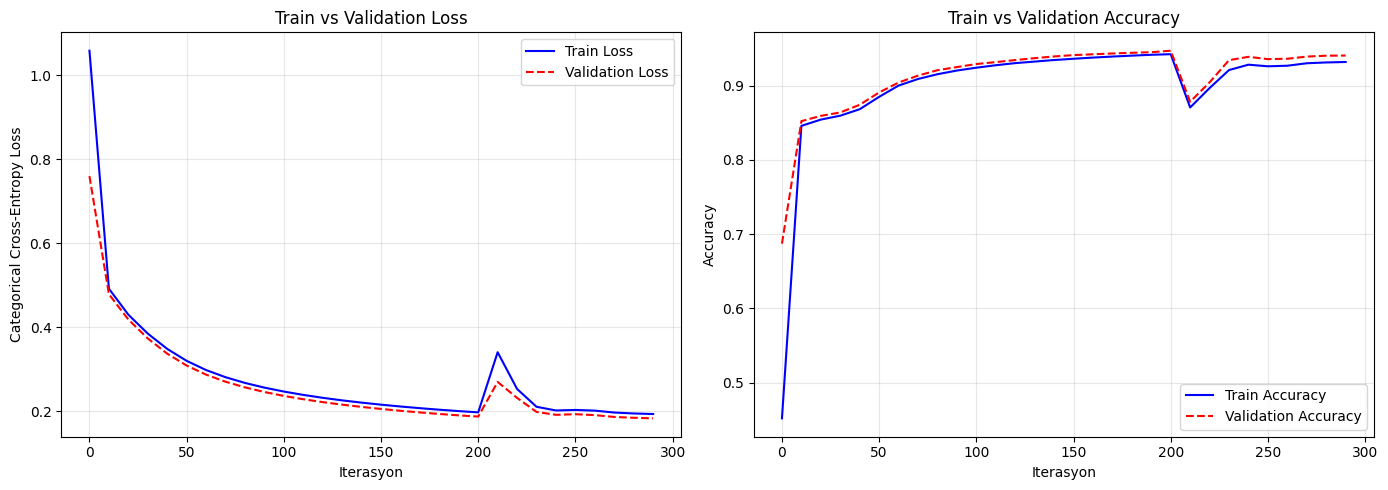

In [33]:
# Train vs Validation Loss ve Accuracy grafikleri
steps_axis = list(range(0, len(train_costs) * 10, 10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(steps_axis, train_costs, 'b-', label='Train Loss')
ax1.plot(steps_axis, val_costs,   'r--', label='Validation Loss')
ax1.set_xlabel('Iterasyon')
ax1.set_ylabel('Categorical Cross-Entropy Loss')
ax1.set_title('Train vs Validation Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(steps_axis, train_accs, 'b-', label='Train Accuracy')
ax2.plot(steps_axis, val_accs,   'r--', label='Validation Accuracy')
ax2.set_xlabel('Iterasyon')
ax2.set_ylabel('Accuracy')
ax2.set_title('Train vs Validation Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [34]:
y_pred_train = predict(parameters, X_train)
y_pred_val   = predict(parameters, X_val)
y_pred_test  = predict(parameters, X_test)

print('Tahminler hazır.')


Tahminler hazır.


In [35]:
# Overfitting teşhisi + tüm metrikler
acc_train = accuracy_score(y_train_raw, y_pred_train)
acc_val   = accuracy_score(y_val_raw,   y_pred_val)
acc_test  = accuracy_score(y_test_raw,  y_pred_test)
gap = acc_train - acc_val

print('=' * 50)
print(f'Train      Accuracy : {acc_train:.4f}')
print(f'Validation Accuracy : {acc_val:.4f}')
print(f'Test       Accuracy : {acc_test:.4f}')
print(f'Train - Val Gap     : {gap:.4f}')
print('=' * 50)

if gap > 0.05:
    print('Durum: OVERFITTING — Regularizasyon veya daha az nöron deneyin.')
elif acc_train < 0.85:
    print('Durum: UNDERFITTING — Daha fazla nöron veya iterasyon deneyin.')
else:
    print('Durum: Iyi fit')

print()
print('Classification Report (Test):')
print(classification_report(y_test_raw, y_pred_test, target_names=le.classes_))


Train      Accuracy : 0.9328
Validation Accuracy : 0.9354
Test       Accuracy : 0.9333
Train - Val Gap     : -0.0026
Durum: Iyi fit

Classification Report (Test):
              precision    recall  f1-score   support

      GALAXY       0.92      0.97      0.95     11895
         QSO       0.95      0.89      0.92      3794
        STAR       0.94      0.88      0.91      4321

    accuracy                           0.93     20010
   macro avg       0.94      0.91      0.93     20010
weighted avg       0.93      0.93      0.93     20010



Confusion Matrix:
[[11499   160   236]
 [  422  3368     4]
 [  511     1  3809]]


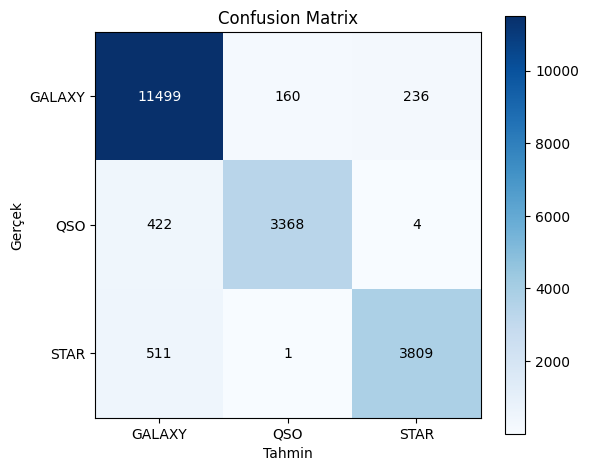

In [36]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test_raw, y_pred_test)
print("Confusion Matrix:")
print(conf_matrix)

# Görsel confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(conf_matrix, cmap='Blues')
plt.colorbar(im)
class_names = le.classes_
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel('Tahmin')
ax.set_ylabel('Gerçek')
ax.set_title('Confusion Matrix')
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, str(conf_matrix[i, j]),
                ha='center', va='center',
                color='white' if conf_matrix[i, j] > conf_matrix.max()/2 else 'black')
plt.tight_layout()
plt.show()

In [37]:
# Detaylı Classification Report
print("Classification Report:")
print(classification_report(y_test_raw, y_pred_test, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.92      0.97      0.95     11895
         QSO       0.95      0.89      0.92      3794
        STAR       0.94      0.88      0.91      4321

    accuracy                           0.93     20010
   macro avg       0.94      0.91      0.93     20010
weighted avg       0.93      0.93      0.93     20010



In [39]:
# Model Seçim Kriteri: val_acc > %90 olanlar arasından en düşük n_steps
print('Hiperparametre arama (n_h ve n_steps):')
print('-' * 60)

candidates = []
for n_h in [16, 32, 64]:
    for n_step in [200, 300, 500]:
        params, _, _, _, _ = nn_model(
            X_train, y_train,
            n_x=X_train.shape[1], n_h=n_h, n_y=num_classes,
            n_steps=n_step, learning_rate=0.5,
            X_val=X_val, Y_val=y_val,
            print_cost=False
        )
        acc_val  = accuracy_score(y_val_raw,  predict(params, X_val))
        acc_test = accuracy_score(y_test_raw, predict(params, X_test))
        candidates.append({'n_h': n_h, 'n_steps': n_step,
                            'val_acc': acc_val, 'test_acc': acc_test})
        print(f'n_h: {n_h:2d}, n_step: {n_step:4d} | val_acc: {acc_val:.4f} | test_acc: {acc_test:.4f}')

passing = [c for c in candidates if c['val_acc'] >= 0.90]
if passing:
    best = min(passing, key=lambda x: x['n_steps'])
    print(f'\n✓ Seçilen model: n_h={best["n_h"]}, n_steps={best["n_steps"]}')
    print(f'  Val Acc={best["val_acc"]:.4f}, Test Acc={best["test_acc"]:.4f}')
else:
    best = max(candidates, key=lambda x: x['val_acc'])
    print(f'\n✓ En iyi model: n_h={best["n_h"]}, n_steps={best["n_steps"]}')


Hiperparametre arama (n_h ve n_steps):
------------------------------------------------------------
n_h: 16, n_step:  200 | val_acc: 0.9389 | test_acc: 0.9352
n_h: 16, n_step:  300 | val_acc: 0.9428 | test_acc: 0.9390
n_h: 16, n_step:  500 | val_acc: 0.9497 | test_acc: 0.9463
n_h: 32, n_step:  200 | val_acc: 0.9453 | test_acc: 0.9415
n_h: 32, n_step:  300 | val_acc: 0.9354 | test_acc: 0.9333
n_h: 32, n_step:  500 | val_acc: 0.9510 | test_acc: 0.9463
n_h: 64, n_step:  200 | val_acc: 0.9461 | test_acc: 0.9431
n_h: 64, n_step:  300 | val_acc: 0.9383 | test_acc: 0.9336
n_h: 64, n_step:  500 | val_acc: 0.9546 | test_acc: 0.9499

✓ Seçilen model: n_h=16, n_steps=200
  Val Acc=0.9389, Test Acc=0.9352
